In [1]:
import os
import glob
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = ""

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'File' in filename:
            with open(os.path.join(dirname, filename), 'r') as f:
                file_data = f.read()
                data += "\n\n" + file_data

print(data[0:5500])



Game started at: 2016/9/23 9:16:13
Game ID: 734105924 2/4 (PRR) Medusa (Short) - 2 (Hold'em)
Seat 6 is the button
Seat 1: AironVega (239.65).
Seat 2: IlxxxlI (114.22).
Seat 3: CKDaimen (118.48).
Seat 4: VanishingFlames (219.70).
Seat 5: Pureprofit4 (427.95).
Seat 6: VegetablesArentYummy (200).
Player AironVega has small blind (2)
Player IlxxxlI has big blind (4)
Player AironVega received a card.
Player AironVega received a card.
Player IlxxxlI received card: [Qs]
Player IlxxxlI received card: [2c]
Player CKDaimen received a card.
Player CKDaimen received a card.
Player VanishingFlames received a card.
Player VanishingFlames received a card.
Player Pureprofit4 received a card.
Player Pureprofit4 received a card.
Player VegetablesArentYummy received a card.
Player VegetablesArentYummy received a card.
Player CKDaimen folds
Player VanishingFlames folds
Player Pureprofit4 folds
Player VegetablesArentYummy folds
Player AironVega folds
Uncalled bet (2) returned to IlxxxlI
Player IlxxxlI mu

In [3]:
games = data.split('\n\n')
print(str(len(games)) + ' played hands.\n\n')
print(games[11])

14008 played hands.


Game started at: 2016/9/23 9:17:37
Game ID: 734106653 2/4 (PRR) Medusa (Short) - 2 (Hold'em)
Seat 3 is the button
Seat 1: AironVega (255.65).
Seat 2: IlxxxlI (120.22).
Seat 3: CKDaimen (112.48).
Seat 4: VanishingFlames (215.70).
Seat 5: Pureprofit4 (415.95).
Seat 6: VegetablesArentYummy (200).
Player VanishingFlames has small blind (2)
Player Pureprofit4 has big blind (4)
Player VanishingFlames received a card.
Player VanishingFlames received a card.
Player Pureprofit4 received a card.
Player Pureprofit4 received a card.
Player VegetablesArentYummy received a card.
Player VegetablesArentYummy received a card.
Player AironVega received a card.
Player AironVega received a card.
Player IlxxxlI received card: [7h]
Player IlxxxlI received card: [Ac]
Player CKDaimen received a card.
Player CKDaimen received a card.
Player VegetablesArentYummy folds
Player AironVega folds
Player IlxxxlI folds
Player CKDaimen calls (4)
Player VanishingFlames calls (2)
Player Pureprofit4 c

In [4]:
def get_preflop_log(game):
    if '*** FLOP ***' in game:
        return game.split('*** FLOP ***')[0]
    else:
        return game.split('------ Summary ------')[0]


preflop_games = [get_preflop_log(game) for game in games]
print(preflop_games[11])

Game started at: 2016/9/23 9:17:37
Game ID: 734106653 2/4 (PRR) Medusa (Short) - 2 (Hold'em)
Seat 3 is the button
Seat 1: AironVega (255.65).
Seat 2: IlxxxlI (120.22).
Seat 3: CKDaimen (112.48).
Seat 4: VanishingFlames (215.70).
Seat 5: Pureprofit4 (415.95).
Seat 6: VegetablesArentYummy (200).
Player VanishingFlames has small blind (2)
Player Pureprofit4 has big blind (4)
Player VanishingFlames received a card.
Player VanishingFlames received a card.
Player Pureprofit4 received a card.
Player Pureprofit4 received a card.
Player VegetablesArentYummy received a card.
Player VegetablesArentYummy received a card.
Player AironVega received a card.
Player AironVega received a card.
Player IlxxxlI received card: [7h]
Player IlxxxlI received card: [Ac]
Player CKDaimen received a card.
Player CKDaimen received a card.
Player VegetablesArentYummy folds
Player AironVega folds
Player IlxxxlI folds
Player CKDaimen calls (4)
Player VanishingFlames calls (2)
Player Pureprofit4 checks



In [5]:
def get_preflop_log(game):
    if '*** FLOP ***' in game:
        return game.split('*** FLOP ***')[0]
    else:
        return game.split('------ Summary ------')[0]


preflop_games = [get_preflop_log(game) for game in games]
print(preflop_games[11])

Game started at: 2016/9/23 9:17:37
Game ID: 734106653 2/4 (PRR) Medusa (Short) - 2 (Hold'em)
Seat 3 is the button
Seat 1: AironVega (255.65).
Seat 2: IlxxxlI (120.22).
Seat 3: CKDaimen (112.48).
Seat 4: VanishingFlames (215.70).
Seat 5: Pureprofit4 (415.95).
Seat 6: VegetablesArentYummy (200).
Player VanishingFlames has small blind (2)
Player Pureprofit4 has big blind (4)
Player VanishingFlames received a card.
Player VanishingFlames received a card.
Player Pureprofit4 received a card.
Player Pureprofit4 received a card.
Player VegetablesArentYummy received a card.
Player VegetablesArentYummy received a card.
Player AironVega received a card.
Player AironVega received a card.
Player IlxxxlI received card: [7h]
Player IlxxxlI received card: [Ac]
Player CKDaimen received a card.
Player CKDaimen received a card.
Player VegetablesArentYummy folds
Player AironVega folds
Player IlxxxlI folds
Player CKDaimen calls (4)
Player VanishingFlames calls (2)
Player Pureprofit4 checks



In [6]:
hero_name = 'IlxxxlI'

def get_heros_cards(game):
    reg_exp = 'Player IlxxxlI received card: \[(.*?)(\w)\]'
    cards_matches = re.findall(reg_exp, game, re.IGNORECASE)

    fc = cards_matches[0][0]
    sc = cards_matches[1][0]
    su = 1 if cards_matches[0][1] == cards_matches[1][1] else 0
    
    return fc, sc, su


def is_broadway_cards(fc, sc):
    fc_is_broadway = fc in ['10', 'J', 'Q', 'K', 'A']
    sc_is_broadway = sc in ['10', 'J', 'Q', 'K', 'A']
    
    if fc_is_broadway == True and sc_is_broadway == False:
        return 2 # uma das cartas é maior ou igual a 10
    elif fc_is_broadway == False and sc_is_broadway == True:
        return 2 # uma das cartas é maior ou igual a 10
    elif fc_is_broadway == True and sc_is_broadway == True:
        return 3 # se as duas cartas são maiores ou igual a 10
    return 1 # nenhuma das cartas são maiores que 10


def transform_card_into_number(card, force_A_1 = False):
    if card == 'K':
        return 13
    if card == 'Q':
        return 12
    if card == 'J':
        return 11
    if card == 'A':
        if force_A_1 == True:
            return 1 # A pode ser visto como 1 ou 14 dependendo do caso
        return 'A'
    
    return int(card)


def get_connection(fc, sc):
    if fc == sc:
        return 1 #'P'
    else:
        fc_aux = transform_card_into_number(fc)
        sc_aux = transform_card_into_number(sc)

        if fc_aux == 'A':
            if sc_aux > 5: #limite baixo
                fc_aux = 14
            else:
                fc_aux = 1
        elif sc_aux == 'A':
            if fc_aux > 5: #limite baixo
                sc_aux = 14
            else:
                sc_aux = 1
        
        sub = abs(fc_aux - sc_aux)
        
        #7 e 8 => 1   7 e 10 => 2
        if sub == 1:
            return 2 #'C'
        elif sub == 2:
            return 3 #'1G'
        elif sub == 3:
            return 4 #'2G'
        elif sub == 4:
            return 5 #'3G'
        return 6 #'D'


def get_hero_position(game):
    sb_match = re.findall('Player IlxxxlI has small blind', game, re.IGNORECASE)
    if len(sb_match) > 0:
        return 1
    
    bb_match = re.findall('Player IlxxxlI has big blind', game, re.IGNORECASE)
    if len(bb_match) > 0:
        return 2
    
    curr_poss = 0
    
    pos_match = re.findall('Player (.*?) received', game, re.IGNORECASE)
    for playername in pos_match:
        if playername == hero_name:
            return curr_poss
        else:
            curr_poss += 1

            
def get_pot(game):
    bb_match = re.findall('big blind \((.*?)\)', game, re.IGNORECASE)
    bb = float(bb_match[0])
    
    sb_match = re.findall('small blind \((.*?)\)', game, re.IGNORECASE)
    sb = float(sb_match[0])
    
    actions_match = re.findall('Player (.*) (calls|raises|caps|allin) \((.*)\)', game, re.IGNORECASE)
    
    total_pot = bb
    
    for action in actions_match:
        if action[0] == hero_name:
            break
        else:
            total_pot += float(action[2])

    return sb, bb, total_pot / bb


def get_vilain_bet(game, pos, bb):
    if pos == 1 or pos == 2 or pos == 3:
        return bb

    actions_match = re.findall('Player (.*) (calls|raises|caps|allin) \((.*)\)', game, re.IGNORECASE)
    
    for action in actions_match:
        if action[0] == hero_name:
            break
        if action[2] in ['raises', 'caps', 'allin']:
            return float(action[2])/float(bb)
    
    return bb

def calculate_pot_odds(game, total_pot, bb):
    spl = re.compile('Player IlxxxlI (calls|raises|caps|allin|folds|mucks|allin)').split(game)
    game_before_hero_action = spl[0]
    
    actions_match = re.findall('Player (.*) (calls|raises|caps|allin|folds|mucks|allin) \((.*)\)', game_before_hero_action, re.IGNORECASE)
    
    last_call_or_raise = bb

    for action in actions_match:            
        last_call_or_raise = float(action[2])

    last_call_or_raise_bb = last_call_or_raise / float(bb)

    return last_call_or_raise_bb  / total_pot

def caracterize_prev_action(game):
    actions_match = re.findall('Player (.*) (checks|calls|raises|caps|folds|mucks|allin)', game, re.IGNORECASE)
    
    num_calls = 0
    num_raises = 0
    num_calls_after_raise = 0
    
    in_raise = False
    for action in actions_match:
        if action[0] == hero_name:
            if num_calls == 0:
                return 1 #'unopened'
            if num_calls == 1 and num_raises == 0:
                return 2 #'limper'
            if num_calls > 1 and num_raises == 0:
                return 3 #'limpers'
            if num_raises == 1 and num_calls_after_raise == 0:
                return 4 #'epraise'
            if num_raises == 1 and num_calls_after_raise > 0:
                return 5 #'epraise_call'
            if num_raises > 1 and num_calls_after_raise == 0:
                return 5 #'2Raise'
            elif num_raises > 1 and num_calls_after_raise > 0:
                return 7 #'2RaiseAndCall'

        actioname = action[1]
        
        if actioname in ['raises', 'caps']:
            num_raises += 1
            in_raise = True
        if actioname == 'calls':
            num_calls += 1
            if in_raise == True:
                num_calls_after_raise += 1
    return None


def get_hero_action(game):
    actions_match = re.findall('Player (.*) (checks|calls|raises|caps|folds|mucks|allin)', game, re.IGNORECASE)
    
    for action in actions_match:
        if action[0] == hero_name:
            actioname = action[1]
            if actioname == 'folds':
                return 0
            if actioname == 'calls':
                return 1
            if actioname == 'raises':
                return 2
            if actioname == 'checks':
                return 3
            if actioname == 'allin':
                return 4

            return -1
    return -1

def calculate_features(game):
    fc, sc, su = get_heros_cards(game)
    broadway = is_broadway_cards(fc, sc)
    conn = get_connection(fc, sc)
    papf = caracterize_prev_action(game)
    pos = get_hero_position(game)
    sb, bb, total_pot = get_pot(game)
    bv = get_vilain_bet(game, pos, bb)
    po = calculate_pot_odds(game, total_pot, bb)
    act = get_hero_action(game)
    
    return {'FC': fc, 'SC': sc, 'SUITED': su, 'BROADWAY': broadway, 'CARDS_CONNECTION': conn, 'POSITION': pos, 'PREVIOUS_ACTION': papf, 'TOTAL_POT': total_pot, 'VILAIN_BET': bv, 'POT_ODDS': po, 'ACT': act}

In [7]:
features = []

for game in preflop_games:
    if len(game.strip()) > 0:
        reg_exp = 'Player IlxxxlI received card: \[(.*?)(\w)\]'
        cards_matches = re.findall(reg_exp, game, re.IGNORECASE)
    
        if len(cards_matches) > 0:
            game_features = calculate_features(game)
            features.append(game_features)

df = pd.DataFrame(features)

df.head(10)

,FC,SC,SUITED,BROADWAY,CARDS_CONNECTION,POSITION,PREVIOUS_ACTION,TOTAL_POT,VILAIN_BET,POT_ODDS,ACT
0,Q,2,0,2,6,2,1,1.0,4.0,1.000000,-1
1,4,3,0,1,2,12,1,3.5,4.0,0.714286,0
2,9,5,1,1,5,1,1,14.0,4.0,0.714286,0
3,4,7,0,1,4,10,2,2.5,4.0,0.400000,0
4,K,9,0,2,5,10,1,1.0,4.0,1.000000,2
5,7,A,0,2,6,8,1,2.5,4.0,0.400000,0
6,9,4,0,1,6,8,1,6.0,4.0,0.166667,0
7,J,10,1,3,2,6,1,1.0,4.0,1.000000,2
8,K,4,1,2,6,4,1,4.0,4.0,0.250000,0
9,7,8,0,1,2,8,1,4.0,4.0,0.250000,0


In [8]:
df = pd.get_dummies(df, columns=['FC', 'SC'])
df.head(10)

,SUITED,BROADWAY,CARDS_CONNECTION,POSITION,PREVIOUS_ACTION,TOTAL_POT,VILAIN_BET,POT_ODDS,ACT,FC_10,...,SC_4,SC_5,SC_6,SC_7,SC_8,SC_9,SC_A,SC_J,SC_K,SC_Q
0,0,2,6,2,1,1.0,4.0,1.000000,-1,False,...,False,False,False,False,False,False,False,False,False,False
1,0,1,2,12,1,3.5,4.0,0.714286,0,False,...,False,False,False,False,False,False,False,False,False,False
2,1,1,5,1,1,14.0,4.0,0.714286,0,False,...,False,True,False,False,False,False,False,False,False,False
3,0,1,4,10,2,2.5,4.0,0.400000,0,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,5,10,1,1.0,4.0,1.000000,2,False,...,False,False,False,False,False,True,False,False,False,False
5,0,2,6,8,1,2.5,4.0,0.400000,0,False,...,False,False,False,False,False,False,True,False,False,False
6,0,1,6,8,1,6.0,4.0,0.166667,0,False,...,True,False,False,False,False,False,False,False,False,False
7,1,3,2,6,1,1.0,4.0,1.000000,2,False,...,False,False,False,False,False,False,False,False,False,False
8,1,2,6,4,1,4.0,4.0,0.250000,0,False,...,True,False,False,False,False,False,False,False,False,False
9,0,1,2,8,1,4.0,4.0,0.250000,0,False,...,False,False,False,False,True,False,False,False,False,False


In [9]:
df = df[df['ACT'] != -1]
df['ACT'].value_counts()

ACT
0    5194
2    1121
1     366
4      75
3      48
Name: count, dtype: int64

In [10]:
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,SUITED,BROADWAY,CARDS_CONNECTION,POSITION,PREVIOUS_ACTION,TOTAL_POT,VILAIN_BET,POT_ODDS,ACT,FC_10,FC_2,FC_3,FC_4,FC_5,FC_6,FC_7,FC_8,FC_9,FC_A,FC_J,FC_K,FC_Q,SC_10,SC_2,SC_3,SC_4,SC_5,SC_6,SC_7,SC_8,SC_9,SC_A,SC_J,SC_K,SC_Q
SUITED,1.000000,0.003678,0.071845,-0.013950,0.003060,-0.004154,-0.004139,0.057150,0.119098,-0.002048,0.022460,-0.005832,-0.007328,0.006230,-0.009845,-0.008071,-0.012516,0.014273,-0.004800,-0.003340,-0.004759,0.016546,-0.002303,0.005048,-0.019479,-0.010129,0.007176,0.002761,-0.025265,0.008656,0.023882,0.019064,0.017552,-0.006504,-0.020586
BROADWAY,0.003678,1.000000,0.028537,-0.009984,-0.020868,-0.057289,-0.006640,0.189670,0.358223,0.262361,-0.169872,-0.160404,-0.155747,-0.149859,-0.155853,-0.162429,-0.176226,-0.131095,0.246891,0.255904,0.257777,0.248027,0.242845,-0.153165,-0.165067,-0.173667,-0.150831,-0.152477,-0.151813,-0.153345,-0.165585,0.259652,0.265014,0.257192,0.246059
CARDS_CONNECTION,0.071845,0.028537,1.000000,-0.007348,0.001867,0.038552,0.022821,-0.157683,-0.326175,-0.016067,0.033768,0.021713,-0.003013,-0.014988,-0.031260,-0.013232,-0.002412,-0.042805,-0.024993,-0.000352,0.064827,0.027177,-0.021303,0.054813,0.018185,-0.021964,-0.020581,-0.002693,-0.009758,-0.002755,-0.034626,-0.018802,-0.024294,0.053178,0.033407
POSITION,-0.013950,-0.009984,-0.007348,1.000000,-0.066086,0.026037,-0.011911,-0.090173,-0.105428,-0.001596,-0.004488,0.034823,0.013088,0.011189,0.007409,-0.015751,-0.005528,-0.004838,-0.015691,0.001390,-0.021404,0.000749,0.012237,-0.008636,0.015377,-0.022152,-0.006422,-0.002557,0.004190,0.005778,0.003920,0.002163,0.007783,-0.007083,-0.004324
PREVIOUS_ACTION,0.003060,-0.020868,0.001867,-0.066086,1.000000,0.127882,-0.025535,-0.206054,-0.021586,0.013662,0.013126,0.005317,0.009956,-0.024341,0.007240,0.024805,0.007289,0.004086,-0.019678,-0.009073,-0.027837,-0.005240,0.021247,-0.004396,0.018189,-0.010250,0.000025,0.004769,0.009453,-0.001653,-0.011178,-0.024067,0.000085,0.002164,-0.004188
TOTAL_POT,-0.004154,-0.057289,0.038552,0.026037,0.127882,1.000000,-0.003198,-0.352782,-0.151868,-0.009144,0.009341,0.024926,0.028895,0.014589,0.023649,0.034587,0.002892,-0.016231,-0.040398,-0.008926,-0.042642,-0.024079,0.017399,0.003284,0.013187,0.007119,0.000670,0.006529,-0.009192,0.001104,-0.002426,-0.039069,-0.010321,0.009418,0.002220
VILAIN_BET,-0.004139,-0.006640,0.022821,-0.011911,-0.025535,-0.003198,1.000000,-0.006165,0.023750,-0.016998,-0.001001,-0.000134,-0.002143,0.007765,-0.003694,-0.007064,-0.006042,0.016457,0.024067,0.015439,-0.015039,-0.010904,-0.002083,0.017596,0.002141,0.000650,0.001473,-0.005974,0.008236,-0.006929,-0.003608,-0.014684,0.009984,0.009989,-0.016297
POT_ODDS,0.057150,0.189670,-0.157683,-0.090173,-0.206054,-0.352782,-0.006165,1.000000,0.440865,0.030310,-0.041864,-0.045494,-0.066691,-0.028008,-0.040435,-0.024657,-0.041863,0.021143,0.085468,0.031626,0.077126,0.047654,-0.004586,-0.036754,-0.050872,-0.037305,-0.047580,-0.013103,-0.004537,-0.031683,0.012139,0.099527,0.044374,0.032008,0.038644
ACT,0.119098,0.358223,-0.326175,-0.105428,-0.021586,-0.151868,0.023750,0.440865,1.000000,0.041033,-0.094090,-0.092785,-0.084219,-0.054557,-0.050373,-0.044464,-0.051486,0.016332,0.206297,0.050121,0.090907,0.074438,0.019571,-0.099794,-0.102810,-0.078871,-0.067846,-0.033494,-0.037837,-0.028891,0.001903,0.212195,0.052024,0.101797,0.061800
FC_10,-0.002048,0.262361,-0.016067,-0.001596,0.013662,-0.009144,-0.016998,0.030310,0.041033,1.000000,-0.080943,-0.083330,-0.085172,-0.082483,-0.080079,-0.084672,-0.083414,-0.079992,-0.080512,-0.082992,-0.082313,-0.082142,-0.027571,0.002933,0.007267,0.004097,-0.002677,-0.016665,-0.000641,0.007705,-0.004517,0.015023,-0.002287,0.012989,0.004738


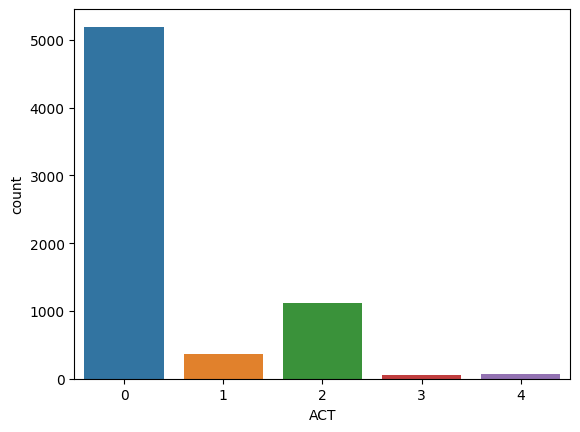

In [11]:
# Distribution of the target variable
sns.countplot(x='ACT', data=df)
plt.show()

In [12]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

X = df.drop('ACT', axis=1)
y = df['ACT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=7)

est = XGBClassifier()
est.fit(X_train, y_train)

y_pred = est.predict(X_test)

print('Acc:', accuracy_score(y_test, y_pred))
print('F1: ',f1_score(y_test, y_pred, average='weighted'))

Acc: 0.9002671415850401
F1:  0.8952931293245224


<Axes: >

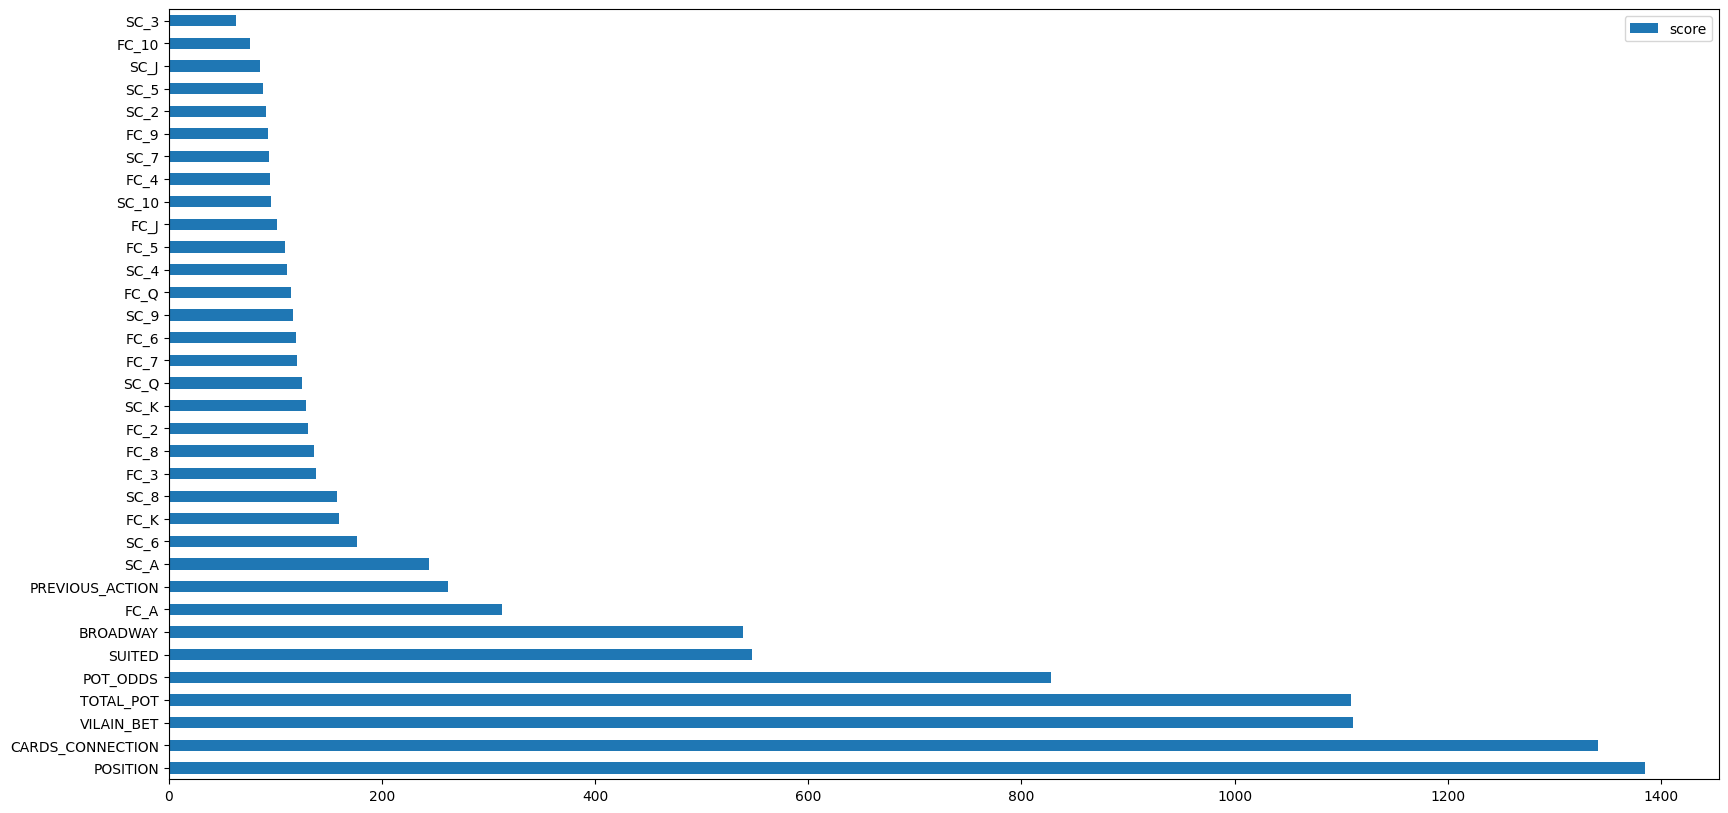

In [13]:
feature_important = est.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(40, columns="score").plot(kind='barh', figsize = (20,10))

In [14]:
feature_important = sorted(feature_important.items(), key=lambda x: x[1], reverse=True)
print(feature_important)

[('POSITION', 1385.0), ('CARDS_CONNECTION', 1341.0), ('VILAIN_BET', 1111.0), ('TOTAL_POT', 1109.0), ('POT_ODDS', 828.0), ('SUITED', 547.0), ('BROADWAY', 539.0), ('FC_A', 313.0), ('PREVIOUS_ACTION', 262.0), ('SC_A', 244.0), ('SC_6', 177.0), ('FC_K', 160.0), ('SC_8', 158.0), ('FC_3', 138.0), ('FC_8', 136.0), ('FC_2', 131.0), ('SC_K', 129.0), ('SC_Q', 125.0), ('FC_7', 120.0), ('FC_6', 119.0), ('SC_9', 117.0), ('FC_Q', 115.0), ('SC_4', 111.0), ('FC_5', 109.0), ('FC_J', 102.0), ('SC_10', 96.0), ('FC_4', 95.0), ('SC_7', 94.0), ('FC_9', 93.0), ('SC_2', 91.0), ('SC_5', 88.0), ('SC_J', 86.0), ('FC_10', 76.0), ('SC_3', 63.0)]


In [15]:
act_mapping = {
    0: 'folds',
    1: 'calls',
    2: 'raises',
    3: 'checks',
    4: 'allin'
}

test = """
Game started at: 2016/9/4 1:51:48
Game ID: 718931171 2/4 (PRR) Monopod (Short) - 2 (Hold'em)
Seat 7 is the button
Seat 1: BIGRAISE (174.47).
Seat 3: cracypoker (231.55).
Seat 5: bjv1105 (522.98).
Seat 6: IlxxxlI (120).
Seat 7: WalterBlack (125).
Seat 8: TheFront7 (265.95).
Player TheFront7 has small blind (20)
Player BIGRAISE has big blind (40)
Player IlxxxlI received card: [9h]
Player IlxxxlI received card: [Kh]
Player TheFront7 received a card.
Player BIGRAISE received a card.
Player BIGRAISE received a card.
Player cracypoker received a card.
Player cracypoker received a card.
Player bjv1105 received a card.
Player bjv1105 received a card.
Player TheFront7 received a card.
Player WalterBlack received a card.
Player WalterBlack received a card.
Player cracypoker folds
Player bjv1105 folds
"""

test_features = calculate_features(test)
test_df = pd.DataFrame([test_features])
test_df = pd.get_dummies(test_df, columns=['FC', 'SC'])

diff_columns = set(df.columns) - set(test_df.columns)

for new_column in diff_columns:
    test_df[new_column] = False

test_df = test_df.drop(['ACT'], axis=1)

y_test = est.predict(test_df.values)

print('Pred action is: ', act_mapping[y_test[0]])

Pred action is:  raises
